Google Colab Lab Assignment Course Name: DEEP LEARNING

Student Name: Nirjara More

Student ID: 202301100049

Date of Submission: 09-04-26

Group Members: Sneha, Vaishnavi, Disha

In [ ]:

# Install extra packages (same as sample does)


!pip install gensim -q
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

# Setup & Imports  (identical to sample Cell 1)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
import math
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk

nltk_packages = [
    'punkt', 'stopwords', 'wordnet',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'punkt_tab'
]
for pkg in nltk_packages:
    try:
        nltk.download(pkg, quiet=True)
    except:
        print(f"Skipping {pkg}")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, ngrams, FreqDist

# ML Libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics.pairwise import cosine_similarity

# Word2Vec  (same as sample Cell 50-51)
from gensim.models import Word2Vec

# SpaCy NER (same as sample Cell 29)
import spacy
nlp = spacy.load("en_core_web_sm")

print("✅ All imports loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All imports loaded successfully


In [ ]:
# Load Dataset  (mirrors sample Cell 2)

def load_dataset(path):
    try:
        df = pd.read_csv(path)
        print("✅ Dataset loaded successfully")
        return df
    except Exception as e:
        print("❌ Error loading dataset:", e)
        return None

id_df = load_dataset("list.csv")   # ← update path if needed

print("\n--- Dataset Summary ---")
print(f"Total rows      : {len(id_df)}")
print(f"Columns         : {id_df.columns.tolist()}")
print(f"Unique newsgroups: {id_df['newsgroup'].unique()}")
print(id_df.head())



✅ Dataset loaded successfully

--- Dataset Summary ---
Total rows      : 628
Columns         : ['newsgroup', 'document_id']
Unique newsgroups: ['talk.religion.misc']
            newsgroup  document_id
0  talk.religion.misc        82757
1  talk.religion.misc        82758
2  talk.religion.misc        82759
3  talk.religion.misc        82760
4  talk.religion.misc        82763


In [ ]:
print("\n⏳ Fetching full text from 20 Newsgroups...")

raw = fetch_20newsgroups(
    subset     = 'all',
    categories = ['talk.religion.misc'],
    remove     = ('headers', 'footers', 'quotes'),
    shuffle    = False
)

# Build dataframe from fetched data
all_docs = pd.DataFrame({
    'filepath' : raw.filenames,
    'message'  : raw.data,
})

# Extract numeric doc ID from file path
all_docs['document_id'] = all_docs['filepath'].apply(
    lambda p: int(re.search(r'(\d+)$', p).group(1))
    if re.search(r'(\d+)$', p) else -1
)

# Filter to IDs in list.csv
valid_ids = set(id_df['document_id'].astype(int).tolist())
df = all_docs[all_docs['document_id'].isin(valid_ids)].copy()
df = df.reset_index(drop=True)

# If too few matched, use all fetched docs
if len(df) < 50:
    print(f"⚠️  Only {len(df)} matched — using full fetched dataset")
    df = all_docs.copy().reset_index(drop=True)

# Drop very short / empty texts
df = df[df['message'].str.strip().str.len() > 30].reset_index(drop=True)

# ── Create binary label (mirrors spam/ham split in sample) ────
# religious = posts containing religion-domain keywords
# general   = all other posts
RELIG_WORDS = ['god','jesus','christian','bible','faith','church',
               'religion','pray','lord','sin','holy','scripture',
               'muslim','islam','allah','christ','prayer','worship']

df['label'] = df['message'].apply(
    lambda t: 'religious' if any(w in t.lower() for w in RELIG_WORDS)
              else 'general'
)

print(f"\n--- Dataset Summary ---")
print(f"Total messages    : {len(df)}")
print(f"Religious messages: {df[df['label']=='religious'].shape[0]}")
print(f"General messages  : {df[df['label']=='general'].shape[0]}")


⏳ Fetching full text from 20 Newsgroups...

--- Dataset Summary ---
Total messages    : 597
Religious messages: 387
General messages  : 210


In [ ]:
# Feature Engineering

df['char_count']  = df['message'].apply(len)
df['word_count']  = df['message'].apply(lambda x: len(x.split()))
df['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['upper_count'] = df['message'].apply(lambda x: sum(c.isupper() for c in x))

print("\n✅ Feature Engineering Done")
print(df[['label','message','char_count','word_count',
          'digit_count','upper_count']].head())



✅ Feature Engineering Done
       label                                            message  char_count  \
0  religious  930418\n\nDo what thou wilt shall be the whole...        6974   
1    general  \n\nSpeaking as one who knows relativity and q...         252   
2  religious  LEWB>> Lets add to those percentages 13-15% fo...         393   
3  religious  I produced an error last week about CHORION:\n...        3258   
4    general  \nThis deserves framing.  It really does.  "[A...         303   

   word_count  digit_count  upper_count  
0        1191           58          289  
1          43            0           12  
2          62            8           34  
3         550            5          129  
4          50            0            7  


In [ ]:
# Exploratory Data Analysis

print("Dataset Shape:", df.shape)

print("\nLabel distribution:")
print(df['label'].value_counts(normalize=True) * 100)

df['msg_length']         = df['message'].apply(len)
df['avg_word_length']    = df['msg_length'] / (df['word_count'] + 1)
df['special_char_count'] = df['message'].apply(
    lambda x: sum(not c.isalnum() for c in x))

print("\n📊 Statistical Summary:")
print(df.groupby('label')[['msg_length','word_count','digit_count']].mean().round(2))

def get_top_words(text_series, n=10):
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

print("\n🔥 Top words in RELIGIOUS:")
print(get_top_words(df[df['label']=='religious']['message']))

print("\n🔥 Top words in GENERAL:")
print(get_top_words(df[df['label']=='general']['message']))


Dataset Shape: (597, 8)

Label distribution:
label
religious    64.824121
general      35.175879
Name: proportion, dtype: float64

📊 Statistical Summary:
           msg_length  word_count  digit_count
label                                         
general        413.09       69.97         1.53
religious     1914.92      322.25         8.73

🔥 Top words in RELIGIOUS:
[('the', 6345), ('of', 3721), ('to', 3386), ('and', 2690), ('that', 2296), ('is', 2176), ('a', 2121), ('in', 1799), ('I', 1722), ('you', 1107)]

🔥 Top words in GENERAL:
[('the', 699), ('of', 377), ('to', 363), ('a', 306), ('that', 301), ('is', 264), ('and', 221), ('I', 196), ('in', 194), ('you', 164)]


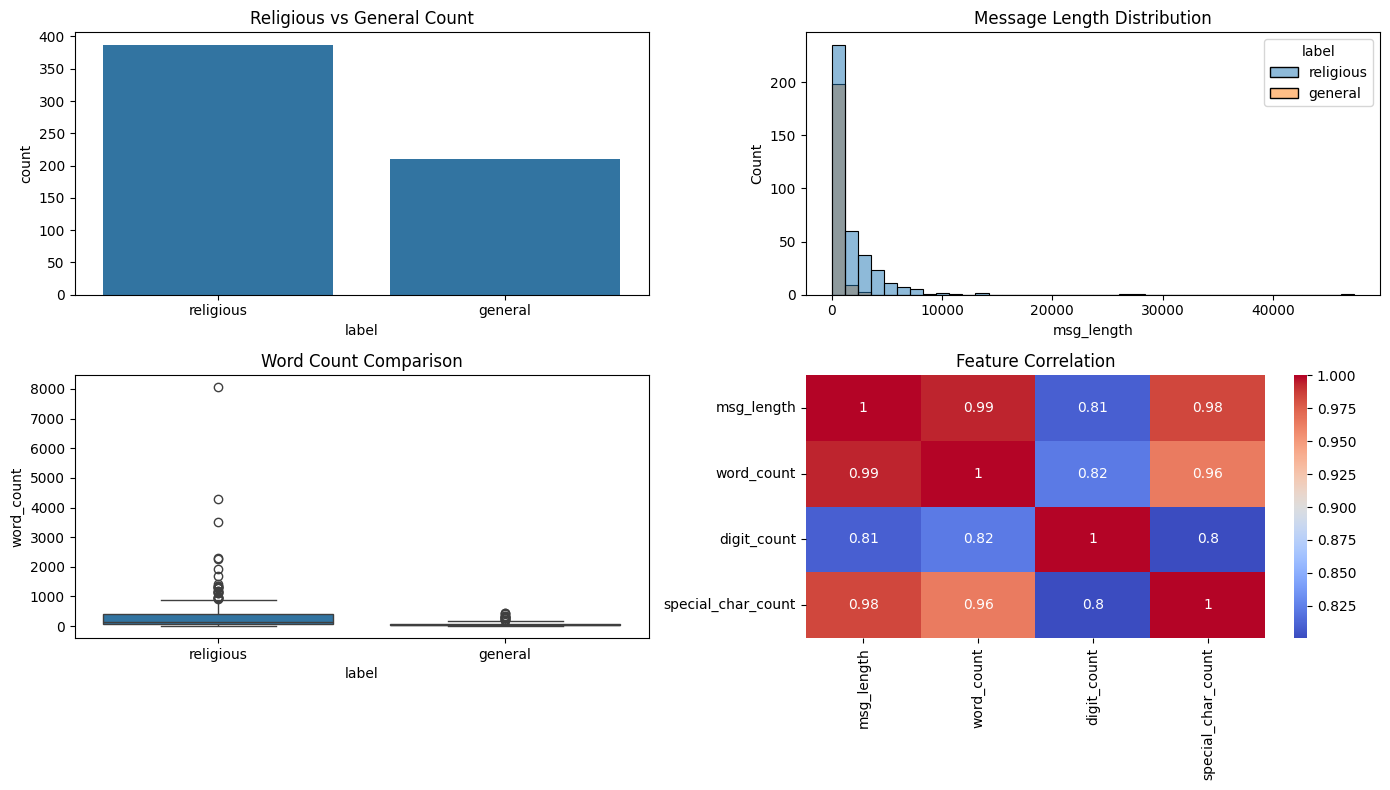

In [ ]:
# Visualization

plt.figure(figsize=(14, 8))

# 1. Label Distribution
plt.subplot(2, 2, 1)
sns.countplot(x='label', data=df)
plt.title("Religious vs General Count")

# 2. Message Length Distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='msg_length', hue='label', bins=40)
plt.title("Message Length Distribution")

# 3. Word Count Boxplot
plt.subplot(2, 2, 3)
sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count Comparison")

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
corr = df[['msg_length','word_count','digit_count','special_char_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation")

plt.tight_layout()
plt.savefig('advanced_eda.png', dpi=120)
plt.show()


NLP Preprocessing from scratch

In [ ]:
# Step 1: Smarter Tokenizer
def manual_tokenize(text):
    text = text.lower()
    for ch in string.punctuation:
        text = text.replace(ch, ' ')
    tokens = []
    for word in text.split():
        if len(word) > 1 and not word.isdigit():
            tokens.append(word)
    return tokens

In [ ]:
# Step 2: Manual Stopwords
MANUAL_STOPWORDS = set([
    'i','me','my','myself','we','our','ours','you','your','yours',
    'he','him','his','she','her','it','its','they','them','their',
    'what','which','who','this','that','these','those','am','is',
    'are','was','were','be','been','being','have','has','had',
    'do','does','did','will','would','shall','should','may','might',
    'must','can','could','a','an','the','and','but','or','so','if',
    'in','on','at','to','for','of','with','by','from','up','about',
    'into','then','than','just','also','very','more','most','some',
    'any','all','no','not','only','same','such','other','each','both'
])

def manual_remove_stopwords(tokens):
    return [t for t in tokens if t not in MANUAL_STOPWORDS]

In [ ]:
# Step 3: Manual Stemming
def manual_stem(word):
    suffixes = ['ization','ational','fulness','ousness','iveness',
                'tion','ing','edly','ed','ly','er','es','s']
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word

def manual_stem_tokens(tokens):
    return [manual_stem(t) for t in tokens]


In [ ]:
# Step 4: Feature Extraction
def extract_manual_features(text):
    return {
        "has_number"     : int(any(c.isdigit() for c in text)),
        "has_uppercase"  : int(any(c.isupper() for c in text)),
        "has_exclamation": int("!" in text),
        "has_url"        : int("http" in text or "www" in text),
        "has_question"   : int("?" in text),
        "word_count"     : len(text.split())
    }

In [ ]:
# Step 5: Full Manual Pipeline
def manual_preprocess(text):
    tokens = manual_tokenize(text)
    tokens = manual_remove_stopwords(tokens)
    tokens = manual_stem_tokens(tokens)
    return ' '.join(tokens)

In [ ]:
# Step 6: Test on sample messages
test_messages = [
    "God is great and we must pray for our sins and seek forgiveness.",
    "The technical conference covered topics on software and networking.",
    "Jesus Christ is the lord and saviour of all Christians who believe."
]

print("=== Manual Preprocessing Test ===")
for msg in test_messages:
    print(f"\nOriginal  : {msg}")
    print(f"Processed : {manual_preprocess(msg)}")

=== Manual Preprocessing Test ===

Original  : God is great and we must pray for our sins and seek forgiveness.
Processed : god great pray sin seek forg

Original  : The technical conference covered topics on software and networking.
Processed : technical conference cover topic software network

Original  : Jesus Christ is the lord and saviour of all Christians who believe.
Processed : jesu christ lord saviour christian believe


In [ ]:
# Step 7: Apply to dataset
print("\nApplying advanced manual preprocessing...")
df['manual_processed'] = df['message'].apply(manual_preprocess)

feature_df = df['message'].apply(
    lambda x: pd.Series(extract_manual_features(x)))
df = pd.concat([df, feature_df], axis=1)
print("✅ Done")
print(df[['label','manual_processed']].head(3))


Applying advanced manual preprocessing...
✅ Done
       label                                   manual_processed
0  religious  thou wilt whole law honest word sin restric ki...
1    general  speak as one know relativity quantum mechanic ...
2  religious  lewb let add percentag orphaic docterian broug...


NLP Preprocessing Using Libraries

In [ ]:
# Advanced NLTK Preprocessing

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def get_wordnet_pos(tag):
    tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB,
               'N': wordnet.NOUN, 'R': wordnet.ADV}
    return tag_map.get(tag[0], wordnet.NOUN)

In [ ]:
def advanced_library_preprocess(text, use_stemming=False):
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Step 3: Tokenization
    tokens = word_tokenize(text)
    # Step 4: Remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # Step 5: POS tagging
    pos_tags = pos_tag(tokens)
    # Step 6: Lemmatization using POS
    lemmatized = [lemmatizer.lemmatize(w, get_wordnet_pos(tag))
                  for w, tag in pos_tags]
    # Step 7: Optional stemming
    if use_stemming:
        lemmatized = [stemmer.stem(w) for w in lemmatized]
    return " ".join(lemmatized)


In [ ]:
# Extra feature extraction
def extract_advanced_features(text):
    return {
        "length"    : len(text),
        "num_digits": sum(c.isdigit() for c in text),
        "num_caps"  : sum(c.isupper() for c in text),
        "num_special": sum(not c.isalnum() for c in text),
        "has_link"  : int("http" in text or "www" in text),
        "has_quote" : int(">" in text or "wrote:" in text.lower())
    }

print("Applying advanced NLP preprocessing...")
df['processed_advanced'] = df['message'].apply(advanced_library_preprocess)

adv_feature_df = df['message'].apply(
    lambda x: pd.Series(extract_advanced_features(x)))

Applying advanced NLP preprocessing...


In [ ]:
# avoid duplicate column names
adv_feature_df.columns = ['adv_' + c for c in adv_feature_df.columns]
df = pd.concat([df, adv_feature_df], axis=1)
print("✅ Done")

# Comparison output  (sample Cell 21)
print("\n🔍 Comparison (Manual vs Advanced NLP)")
print("=" * 70)
for i in range(3):
    print(f"\nOriginal  : {df['message'].iloc[i][:80]}")
    print(f"Manual    : {df['manual_processed'].iloc[i][:80]}")
    print(f"NLTK Adv  : {df['processed_advanced'].iloc[i][:80]}")

✅ Done

🔍 Comparison (Manual vs Advanced NLP)

Original  : 930418

Do what thou wilt shall be the whole of the Law. [Honestly.]
The word of
Manual    : thou wilt whole law honest word sin restric kid one man word encompas majestic v
NLTK Adv  : thou wilt shall whole law honestly word sin restriction would kid one man word e

Original  : 

Speaking as one who knows relativity and quantum mechanics, I say: 
Bullshit.

Manual    : speak as one know relativity quantum mechanic say bullshit speak as one taken ls
NLTK Adv  : speak one know relativity quantum mechanic say bullshit speak one take lsd say b

Original  : LEWB>> Lets add to those percentages 13-15% for the Orphaic docterians
brought L
Manual    : lewb let add percentag orphaic docterian brought lewb group paul saul high rank 
NLTK Adv  : lewb let add percentage orphaic docterians bring lewbto group paulsaul high rank


POS Tagging

In [ ]:
# POS Tagging

# Scratch POS Tagger
def improved_scratch_pos_tagger(tokens):
    tagged = []
    for word in tokens:
        if word in ['is','are','was','were','be','been','am',
                    'have','has','do','does']:
            tag = 'VB'
        elif word.endswith('ing'):
            tag = 'VBG'
        elif word.endswith('ed'):
            tag = 'VBD'
        elif word.endswith('ly'):
            tag = 'RB'
        elif word.endswith(('ous','ful','able','ive')):
            tag = 'JJ'
        elif word.endswith(('tion','ness','ment')):
            tag = 'NN'
        elif word.isdigit():
            tag = 'CD'
        elif len(word) <= 2:
            tag = 'IN'
        else:
            tag = 'NN'
        tagged.append((word, tag))
    return tagged


In [ ]:
# Demo scratch POS
sample_tokens = manual_tokenize(df['message'].iloc[0])[:10]
print("\n🔖 Scratch POS Tags (first 10 tokens):")
print(improved_scratch_pos_tagger(sample_tokens))


🔖 Scratch POS Tags (first 10 tokens):
[('do', 'VB'), ('what', 'NN'), ('thou', 'NN'), ('wilt', 'NN'), ('shall', 'NN'), ('be', 'VB'), ('the', 'NN'), ('whole', 'NN'), ('of', 'IN'), ('the', 'NN')]


In [ ]:
# NLTK POS distribution per class
def get_pos_distribution(text_series):
    pos_counts = Counter()
    for text in text_series:
        tokens = word_tokenize(str(text))
        tags   = pos_tag(tokens)
        for _, tag in tags:
            pos_counts[tag[:2]] += 1
    return pos_counts

print("\n⏳ Computing POS distributions (200 docs each)...")
relig_pos = get_pos_distribution(
    df[df['label']=='religious']['message'].head(200))
gen_pos   = get_pos_distribution(
    df[df['label']=='general']['message'].head(200))

print("Religious POS Distribution:", relig_pos.most_common(6))
print("General   POS Distribution:", gen_pos.most_common(6))



⏳ Computing POS distributions (200 docs each)...
Religious POS Distribution: [('NN', 18084), ('VB', 12670), ('IN', 8375), ('DT', 6892), ('PR', 5575), ('JJ', 5048)]
General   POS Distribution: [('NN', 3905), ('VB', 2745), ('IN', 1707), ('DT', 1506), ('JJ', 1161), ('PR', 1104)]


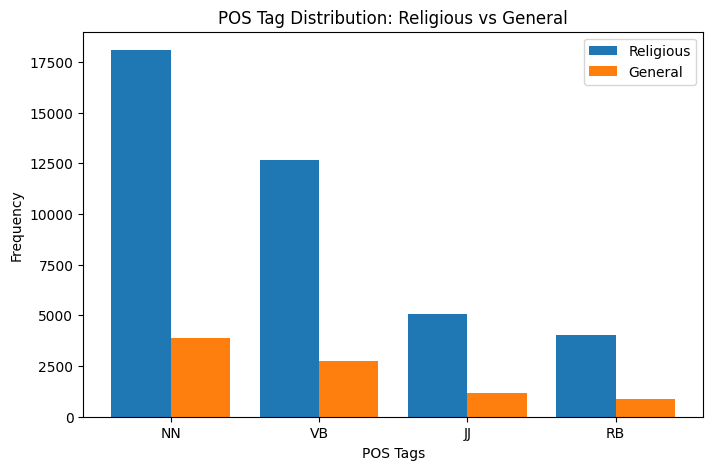

In [ ]:
# POS Comparison Plot
common_tags  = ['NN','VB','JJ','RB']
relig_values = [relig_pos.get(t,0) for t in common_tags]
gen_values   = [gen_pos.get(t,0)   for t in common_tags]
x = range(len(common_tags))

plt.figure(figsize=(8, 5))
plt.bar(x,             relig_values, width=0.4, label='Religious')
plt.bar([i+0.4 for i in x], gen_values, width=0.4, label='General')
plt.xticks([i+0.2 for i in x], common_tags)
plt.title("POS Tag Distribution: Religious vs General")
plt.xlabel("POS Tags"); plt.ylabel("Frequency")
plt.legend(); plt.show()

In [ ]:
# POS Comparison Table
print("\n📊 POS Comparison Table")
print("-" * 40)
print(f"{'POS':<10}{'Religious':<15}{'General':<10}")
for tag in common_tags:
    print(f"{tag:<10}{relig_pos.get(tag,0):<15}{gen_pos.get(tag,0):<10}")


📊 POS Comparison Table
----------------------------------------
POS       Religious      General   
NN        18084          3905      
VB        12670          2745      
JJ        5048           1161      
RB        4036           891       


Named Entity Recognition (NER)

In [ ]:
# NER

# Scratch NER
def improved_scratch_ner(tokens):
    entities = []
    org_keywords   = ['church','bible','quran','vatican','mosque',
                      'christianity','islam','judaism']
    person_titles  = ['mr','mrs','miss','dr','sir','prophet','saint']
    place_keywords = ['jerusalem','rome','mecca','israel','india',
                      'egypt','london','usa']
    i = 0
    while i < len(tokens):
        word = tokens[i].lower()
        if any(sym in word for sym in ['£','$','rs']):
            entities.append((tokens[i], 'MONEY'))
        elif word.isdigit() and len(word) >= 5:
            entities.append((tokens[i], 'PHONE/NUMBER'))
        elif word in person_titles and i+1 < len(tokens):
            entities.append((tokens[i]+' '+tokens[i+1], 'PERSON'))
            i += 1
        elif word in place_keywords:
            entities.append((tokens[i], 'PLACE'))
        elif word in org_keywords:
            entities.append((tokens[i], 'ORGANIZATION'))
        elif tokens[i][0].isupper() and i > 0 and len(tokens[i]) > 2:
            entities.append((tokens[i], 'PROPER_NOUN'))
        i += 1
    return entities

In [ ]:
# Demo scratch NER
sample_ner_tokens = manual_tokenize(df['message'].iloc[0])
print("\n🏷️  Scratch NER Demo:")
print(improved_scratch_ner(sample_ner_tokens)[:8])


🏷️  Scratch NER Demo:
[('members', 'MONEY'), ('years', 'MONEY'), ('orders', 'MONEY'), ('perspectives', 'MONEY'), ('first', 'MONEY'), ('leadership', 'MONEY'), ('usa', 'PLACE'), ('first', 'MONEY')]


In [ ]:
# SpaCy NER
def spacy_ner(text):
    doc = nlp(str(text)[:500])   # limit length for speed
    return [(ent.text, ent.label_) for ent in doc.ents]

# Entity distribution per class
def get_entity_distribution(text_series, ner_function, limit=200):
    entity_counts = Counter()
    texts = list(text_series)[:limit]
    for text in texts:
        entities = ner_function(text)
        for _, label in entities:
            entity_counts[label] += 1
    return entity_counts

relig_texts = df[df['label']=='religious']['message']
gen_texts   = df[df['label']=='general']['message']

relig_entities = get_entity_distribution(relig_texts, spacy_ner)
gen_entities   = get_entity_distribution(gen_texts,   spacy_ner)

print("\nReligious Entity Distribution:", relig_entities)
print("General   Entity Distribution:", gen_entities)


Religious Entity Distribution: Counter({'PERSON': 312, 'ORG': 166, 'NORP': 156, 'CARDINAL': 108, 'DATE': 69, 'GPE': 68, 'WORK_OF_ART': 52, 'ORDINAL': 27, 'PRODUCT': 8, 'MONEY': 7, 'TIME': 6, 'LOC': 6, 'LAW': 6, 'PERCENT': 5, 'FAC': 2, 'EVENT': 2, 'LANGUAGE': 2, 'QUANTITY': 1})
General   Entity Distribution: Counter({'PERSON': 154, 'ORG': 79, 'CARDINAL': 65, 'GPE': 41, 'DATE': 31, 'NORP': 29, 'ORDINAL': 22, 'WORK_OF_ART': 21, 'LOC': 7, 'MONEY': 7, 'QUANTITY': 6, 'PRODUCT': 5, 'TIME': 4, 'PERCENT': 3, 'EVENT': 2, 'LAW': 1, 'FAC': 1})


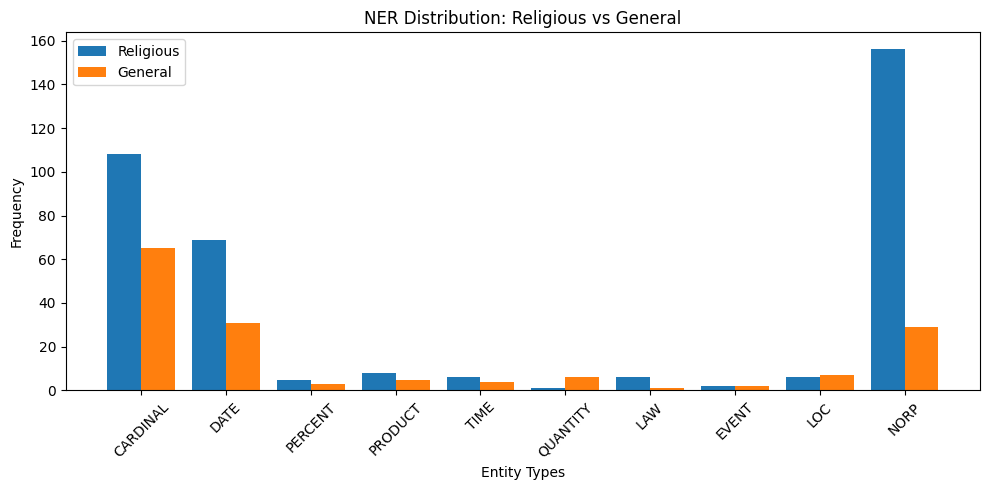

In [ ]:
# Entity Comparison Plot
common_entities = list(
    set(list(relig_entities.keys()) + list(gen_entities.keys())))[:10]
relig_vals = [relig_entities.get(e,0) for e in common_entities]
gen_vals   = [gen_entities.get(e,0)   for e in common_entities]

x = range(len(common_entities))
plt.figure(figsize=(10, 5))
plt.bar(x,             relig_vals, width=0.4, label='Religious')
plt.bar([i+0.4 for i in x], gen_vals, width=0.4, label='General')
plt.xticks([i+0.2 for i in x], common_entities, rotation=45)
plt.title("NER Distribution: Religious vs General")
plt.xlabel("Entity Types");
plt.ylabel("Frequency")
plt.legend();
plt.tight_layout();
plt.show()

In [ ]:
print("=== Stemming vs Lemmatization Demo ===")
sample_words = ['running','believing','praying','gods','churches',
                'sins','blessed','written','having','preacher']

print(f"\n{'Word':<20}{'Stemmed':<20}{'Lemmatized'}")
print("-" * 55)
for word in sample_words:
    stemmed = stemmer.stem(word)
    lemma   = lemmatizer.lemmatize(word, 'v')
    print(f"{word:<20}{stemmed:<20}{lemma}")

# Full lemmatization pipeline applied to dataset
def lemmatized_preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tags   = pos_tag(tokens)
    result = [lemmatizer.lemmatize(w, get_wordnet_pos(tag))
              for w, tag in tags]
    return " ".join(result)

print("\n⏳ Applying lemmatization to dataset...")
df['lemmatized_processed'] = df['message'].apply(lemmatized_preprocess)
print("✅ Done")


=== Stemming vs Lemmatization Demo ===

Word                Stemmed             Lemmatized
-------------------------------------------------------
running             run                 run
believing           believ              believe
praying             pray                pray
gods                god                 gods
churches            church              church
sins                sin                 sin
blessed             bless               bless
written             written             write
having              have                have
preacher            preacher            preacher

⏳ Applying lemmatization to dataset...
✅ Done


Text Vectorization

In [ ]:
# Word2Vec

# BLOCK 1: Prepare sentences
sentences = [word_tokenize(t.lower())
             for t in df['lemmatized_processed']]

# BLOCK 2: Train Word2Vec
print("Training Word2Vec model...")
w2v_model = Word2Vec(
    sentences   = sentences,
    vector_size = 100,
    window      = 5,
    min_count   = 2,
    epochs      = 15,
    sg          = 1
)
print("Vocabulary size:", len(w2v_model.wv.key_to_index))
print("Vector size    :", w2v_model.vector_size)


Training Word2Vec model...
Vocabulary size: 4915
Vector size    : 100


In [ ]:
# BLOCK 3: Similar words
keywords = ['god','church','faith','prayer']
for word in keywords:
    if word in w2v_model.wv:
        print(f"\nWords similar to '{word}':")
        for w, sim in w2v_model.wv.most_similar(word, topn=5):
            print(f"  {w:<15} {sim:.4f}")



Words similar to 'god':
  obedience       0.7860
  obey            0.7800
  whosoever       0.7721
  idolatry        0.7699
  triune          0.7656

Words similar to 'church':
  lds             0.7640
  boldly          0.7324
  rlds            0.7317
  misrepresentation 0.7202
  council         0.7130

Words similar to 'faith':
  divinity        0.7889
  profess         0.7879
  arm             0.7793
  tutor           0.7750
  natlamp         0.7728

Words similar to 'prayer':
  school          0.8316
  moment          0.7363
  pray            0.7298
  manage          0.7198
  song            0.7092


In [ ]:
# BLOCK 4: Word pair similarity
pairs = [('god','jesus'), ('church','religion'),
         ('faith','belief'), ('prayer','worship')]
print("\nWord2Vec Similarity:")
for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = w2v_model.wv.similarity(w1, w2)
        print(f"{w1:<12} <-> {w2:<12} : {sim:.4f}")


Word2Vec Similarity:
god          <-> jesus        : 0.5836
church       <-> religion     : 0.3493
faith        <-> belief       : 0.5154
prayer       <-> worship      : 0.5455


In [ ]:
# BLOCK 5: Sentence vectors
def sentence_vector(sentence):
    words   = sentence.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if not vectors:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vectors, axis=0)

df['w2v_vector'] = df['lemmatized_processed'].apply(sentence_vector)
print("\nVector length:", len(df['w2v_vector'].iloc[0]))



Vector length: 100


In [ ]:
# BLOCK 6: Prepare feature matrix
X_w2v = np.vstack(df['w2v_vector'].values)
print("Feature matrix shape:", X_w2v.shape)


Feature matrix shape: (597, 100)


N-Gram

In [ ]:
#  N-Grams

# APPROACH 1: From Scratch
def scratch_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

relig_example = df[df['label']=='religious']['message'].iloc[0]
gen_example   = df[df['label']=='general']['message'].iloc[0]
relig_tokens  = manual_tokenize(relig_example)
gen_tokens    = manual_tokenize(gen_example)

print("=== FROM SCRATCH N-Grams ===")
print("\nReligious message:", relig_example[:80])
print("Bigrams  :", scratch_ngrams(relig_tokens, 2)[:5])
print("Trigrams :", scratch_ngrams(relig_tokens, 3)[:5])

print("\nGeneral message:", gen_example[:80])
print("Bigrams  :", scratch_ngrams(gen_tokens, 2)[:5])
print("Trigrams :", scratch_ngrams(gen_tokens, 3)[:5])

=== FROM SCRATCH N-Grams ===

Religious message: 930418

Do what thou wilt shall be the whole of the Law. [Honestly.]
The word of
Bigrams  : [('do', 'what'), ('what', 'thou'), ('thou', 'wilt'), ('wilt', 'shall'), ('shall', 'be')]
Trigrams : [('do', 'what', 'thou'), ('what', 'thou', 'wilt'), ('thou', 'wilt', 'shall'), ('wilt', 'shall', 'be'), ('shall', 'be', 'the')]

General message: 

Speaking as one who knows relativity and quantum mechanics, I say: 
Bullshit.

Bigrams  : [('speaking', 'as'), ('as', 'one'), ('one', 'who'), ('who', 'knows'), ('knows', 'relativity')]
Trigrams : [('speaking', 'as', 'one'), ('as', 'one', 'who'), ('one', 'who', 'knows'), ('who', 'knows', 'relativity'), ('knows', 'relativity', 'and')]


In [ ]:
# APPROACH 2: NLTK
print("\n=== WITH LIBRARY (NLTK) N-Grams ===")

def get_top_ngrams(text_series, n=2, top_k=5):
    all_tokens = []
    for msg in text_series:
        tokens = word_tokenize(str(msg).lower())
        all_tokens.extend(tokens)
    return FreqDist(list(ngrams(all_tokens, n))).most_common(top_k)

print("\nTop Bigrams  (Religious):", get_top_ngrams(relig_texts, 2))
print("Top Bigrams  (General)  :", get_top_ngrams(gen_texts,   2))
print("\nTop Trigrams (Religious):", get_top_ngrams(relig_texts, 3))
print("Top Trigrams (General)  :", get_top_ngrams(gen_texts,   3))



=== WITH LIBRARY (NLTK) N-Grams ===

Top Bigrams  (Religious): [(('of', 'the'), 934), ((',', 'and'), 825), (('--', '--'), 633), (('in', 'the'), 534), (('.', 'i'), 483)]
Top Bigrams  (General)  : [(('*', '*'), 270), (('of', 'the'), 110), (('.', 'i'), 65), ((',', 'and'), 61), (('in', 'the'), 46)]

Top Trigrams (Religious): [(('--', '--', '--'), 584), (('*', '*', '*'), 248), (('i', 'do', "n't"), 111), (('[', 'jehovah', ']'), 88), ((',', 'and', 'the'), 85)]
Top Trigrams (General)  : [(('*', '*', '*'), 255), (('--', '--', '--'), 41), ((':', '-', ')'), 20), (('.', 'it', 'is'), 17), (('i', 'do', "n't"), 15)]


In [ ]:
# APPROACH 3: sklearn
print("\n=== EXISTING MODEL (sklearn) N-Grams ===")

bigram_vec = CountVectorizer(ngram_range=(2,2), max_features=20, min_df=2)
bigram_vec.fit(df['lemmatized_processed'])

relig_idx = np.where(df['label']=='religious')[0]
gen_idx   = np.where(df['label']=='general')[0]
X_bg      = bigram_vec.transform(df['lemmatized_processed'])

relig_counts = np.asarray(X_bg[relig_idx].sum(axis=0)).flatten()
gen_counts   = np.asarray(X_bg[gen_idx].sum(axis=0)).flatten()
bg_features  = bigram_vec.get_feature_names_out()

print(f"\n{'Bigram':<30}{'Religious':<15}{'General':<10}")
print("-" * 55)
for i, bg in enumerate(bg_features):
    print(f"{bg:<30}{relig_counts[i]:<15}{gen_counts[i]:<10}")


=== EXISTING MODEL (sklearn) N-Grams ===

Bigram                        Religious      General   
-------------------------------------------------------
bible teach                   18             0         
cheer kent                    25             12        
david koresh                  22             4         
eternal life                  20             0         
god god                       21             0         
jesus christ                  57             0         
jesus say                     23             0         
many people                   27             1         
moral system                  12             8         
new testament                 20             0         
objective morality            16             4         
physical universe             25             1         
promise messiah               21             0         
quote context                 22             7         
say unto                      23             0         
son g

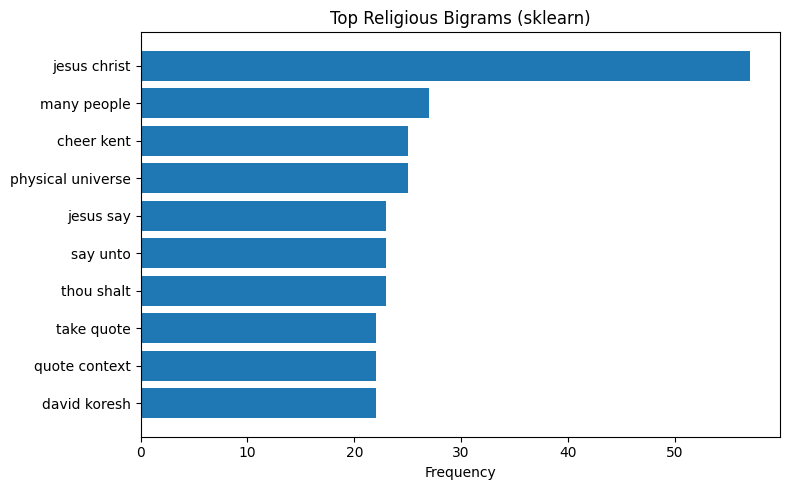

In [ ]:
# Top bigrams bar plot
top_idx  = relig_counts.argsort()[::-1][:10]
top_bg   = [bg_features[i] for i in top_idx]
top_vals = [relig_counts[i] for i in top_idx]

plt.figure(figsize=(8, 5))
plt.barh(top_bg[::-1], top_vals[::-1])
plt.title("Top Religious Bigrams (sklearn)")
plt.xlabel("Frequency"); plt.tight_layout(); plt.show()

Text Similarity

In [ ]:
# Text Similarity

# BLOCK 1: Scratch Cosine Similarity
def scratch_text_vectorize(text, vocab):
    tokens = manual_tokenize(text)
    vector = np.zeros(len(vocab))
    for word in tokens:
        if word in vocab:
            vector[vocab[word]] += 1
    return vector

def scratch_cosine_similarity(text1, text2):
    t1 = manual_tokenize(text1)
    t2 = manual_tokenize(text2)
    vocab = {w: i for i, w in enumerate(set(t1 + t2))}
    v1 = scratch_text_vectorize(text1, vocab)
    v2 = scratch_text_vectorize(text2, vocab)
    dot  = np.dot(v1, v2)
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot / norm if norm != 0 else 0.0

relig_msgs = df[df['label']=='religious']['message'].head(3).tolist()
gen_msgs   = df[df['label']=='general']['message'].head(3).tolist()

print("=== Scratch Similarity ===")
print("\nReligious vs Religious:",
      round(scratch_cosine_similarity(relig_msgs[0], relig_msgs[1]), 4))
print("Religious vs General  :",
      round(scratch_cosine_similarity(relig_msgs[0], gen_msgs[0]),   4))
print("General   vs General  :",
      round(scratch_cosine_similarity(gen_msgs[0],   gen_msgs[1]),   4))

=== Scratch Similarity ===

Religious vs Religious: 0.4969
Religious vs General  : 0.237
General   vs General  : 0.0314


In [ ]:
# BLOCK 2: TF-IDF Cosine Similarity
tfidf_sim    = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
tfidf_matrix = tfidf_sim.fit_transform(df['message'].astype(str))

query_idx  = df[df['label']=='religious'].index[0]
query_vec  = tfidf_matrix[query_idx]
query_text = df.loc[query_idx, 'message']

sim_scores  = cosine_similarity(query_vec, tfidf_matrix).flatten()
top_sim_idx = sim_scores.argsort()[::-1][:5]

print("\nQuery Message:")
print(query_text[:80])
print("\nTop 5 Similar Messages (TF-IDF Cosine):")
for i in top_sim_idx:
    print(f"\n[{df.loc[i,'label'].upper()}] Score: {sim_scores[i]:.4f}")
    print(df.loc[i,'message'][:80])


Query Message:
930418

Do what thou wilt shall be the whole of the Law. [Honestly.]
The word of

Top 5 Similar Messages (TF-IDF Cosine):

[RELIGIOUS] Score: 1.0000
930418

Do what thou wilt shall be the whole of the Law. [Honestly.]
The word of

[RELIGIOUS] Score: 0.5506
93!04.16 e.v.  After the Glorious Eve of Taxation

Do what thou wilt shall be th

[RELIGIOUS] Score: 0.4819
In <lsjc8cINNmc1@saltillo.cs.utexas.edu> turpin@cs.utexas.edu (Russell Turpin)



[RELIGIOUS] Score: 0.4757
Why should anyone (check: let's restrict this to Christians, why do *we*)
want t

[RELIGIOUS] Score: 0.4683

#In <mcclaryC5snpq.KB1@netcom.com> mcclary@netcom.com (Michael McClary)
#      


Classification Models

In [ ]:
# Manual Naive Bayes from Scratch

class ManualNaiveBayes:
    def __init__(self):
        self.class_probs = {}
        self.word_probs  = defaultdict(dict)
        self.vocab       = set()
        self.classes     = []

    def fit(self, X_train, y_train):
        self.classes  = list(set(y_train))
        total_docs    = len(y_train)
        class_docs    = {cls: [] for cls in self.classes}
        for text, label in zip(X_train, y_train):
            class_docs[label].append(text)
        # Prior probabilities
        for cls in self.classes:
            self.class_probs[cls] = len(class_docs[cls]) / total_docs
        # Build vocab
        for cls in self.classes:
            for doc in class_docs[cls]:
                for word in doc.split():
                    self.vocab.add(word)
        # Word probabilities (Laplace smoothing)
        for cls in self.classes:
            all_words   = " ".join(class_docs[cls]).split()
            word_counts = Counter(all_words)
            total_words = len(all_words)
            for word in self.vocab:
                self.word_probs[cls][word] = (
                    (word_counts.get(word, 0) + 1) /
                    (total_words + len(self.vocab))
                )

    def predict_one(self, text):
        words      = text.split()
        best_cls   = None
        best_score = float('-inf')
        for cls in self.classes:
            score = math.log(self.class_probs[cls])
            for word in words:
                if word in self.word_probs[cls]:
                    score += math.log(self.word_probs[cls][word])
            if score > best_score:
                best_score = score
                best_cls   = cls
        return best_cls

    def predict(self, X_test):
        return [self.predict_one(text) for text in X_test]

# Prepare data
df['label_encoded'] = (df['label'] == 'religious').astype(int)

X_text = df['lemmatized_processed']
y      = df['label']

X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

print("Training Manual Naive Bayes...")
mnb = ManualNaiveBayes()
mnb.fit(X_tr_raw.tolist(), y_tr_raw.tolist())
print("✅ Training complete")
print("Vocabulary size    :", len(mnb.vocab))
print("Class probabilities:", mnb.class_probs)

Training Manual Naive Bayes...
✅ Training complete
Vocabulary size    : 8338
Class probabilities: {'general': 0.3522012578616352, 'religious': 0.6477987421383647}


In [ ]:
# BLOCK 4: Evaluation
y_pred_manual = mnb.predict(X_te_raw.tolist())
acc = accuracy_score(y_te_raw.tolist(), y_pred_manual)
f1  = f1_score(y_te_raw.tolist(), y_pred_manual,
               pos_label='religious', average='binary')

print("\nManual Naive Bayes Results:")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_te_raw.tolist(), y_pred_manual,
                             target_names=['general','religious']))


Manual Naive Bayes Results:
Accuracy : 0.7083
F1 Score : 0.8087

Classification Report:
              precision    recall  f1-score   support

     general       0.73      0.26      0.39        42
   religious       0.70      0.95      0.81        78

    accuracy                           0.71       120
   macro avg       0.72      0.61      0.60       120
weighted avg       0.71      0.71      0.66       120



In [ ]:
# Vectorization + sklearn Models

y_enc = df['label_encoded']

# CountVectorizer
cv_vec = CountVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_cv   = cv_vec.fit_transform(df['lemmatized_processed'])

# TF-IDF
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                             sublinear_tf=True, min_df=2)
X_tfidf   = tfidf_vec.fit_transform(df['lemmatized_processed'])

X_train_cv, X_test_cv, y_train, y_test = train_test_split(
    X_cv, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f"Train size : {X_train_cv.shape[0]}")
print(f"Test  size : {X_test_cv.shape[0]}")

# Define models (exactly as sample)
models = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM'         : LinearSVC(random_state=42, max_iter=1000)
}

vectorizers = {
    'CountVectorizer': (X_train_cv,    X_test_cv),
    'TF-IDF'         : (X_train_tfidf, X_test_tfidf),
}

results = []

print("Training models...")
print("=" * 60)

for vec_name, (X_tr, X_te) in vectorizers.items():
    print(f"\nVectorizer: {vec_name}")
    print("-" * 40)

    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)

        results.append({
            'Model'     : model_name,
            'Vectorizer': vec_name,
            'Accuracy'  : acc,
            'F1 Score'  : f1,
            'y_pred'    : y_pred
        })

        print(f"  {model_name:<25} Acc={acc:.4f}  F1={f1:.4f}")

results_df = pd.DataFrame(results)


Train size : 477
Test  size : 120
Training models...

Vectorizer: CountVectorizer
----------------------------------------
  Naive Bayes               Acc=0.7667  F1=0.7407
  Logistic Regression       Acc=0.8417  F1=0.8269
  Linear SVM                Acc=0.7833  F1=0.7667

Vectorizer: TF-IDF
----------------------------------------
  Naive Bayes               Acc=0.6583  F1=0.4192
  Logistic Regression       Acc=0.6833  F1=0.5052
  Linear SVM                Acc=0.7667  F1=0.7341


In [ ]:
# Best Model + Report
best_row = results_df.loc[results_df['F1 Score'].idxmax()]

print("\n🔥 Best Model:")
print(best_row[['Model','Vectorizer','Accuracy','F1 Score']])

print("\nSummary Table:")
print(results_df[['Model','Vectorizer','Accuracy','F1 Score']].to_string(index=False))

# Detailed classification report for best model
best_pred = best_row['y_pred']
print(f"\nClassification Report — {best_row['Model']} ({best_row['Vectorizer']}):")
print(classification_report(y_test, best_pred,
                             target_names=['general','religious'], digits=4))




🔥 Best Model:
Model         Logistic Regression
Vectorizer        CountVectorizer
Accuracy                 0.841667
F1 Score                 0.826945
Name: 1, dtype: object

Summary Table:
              Model      Vectorizer  Accuracy  F1 Score
        Naive Bayes CountVectorizer  0.766667  0.740661
Logistic Regression CountVectorizer  0.841667  0.826945
         Linear SVM CountVectorizer  0.783333  0.766746
        Naive Bayes          TF-IDF  0.658333  0.419195
Logistic Regression          TF-IDF  0.683333  0.505208
         Linear SVM          TF-IDF  0.766667  0.734093

Classification Report — Logistic Regression (CountVectorizer):
              precision    recall  f1-score   support

     general     0.7674    0.7857    0.7765        42
   religious     0.8831    0.8718    0.8774        78

    accuracy                         0.8417       120
   macro avg     0.8253    0.8288    0.8269       120
weighted avg     0.8426    0.8417    0.8421       120



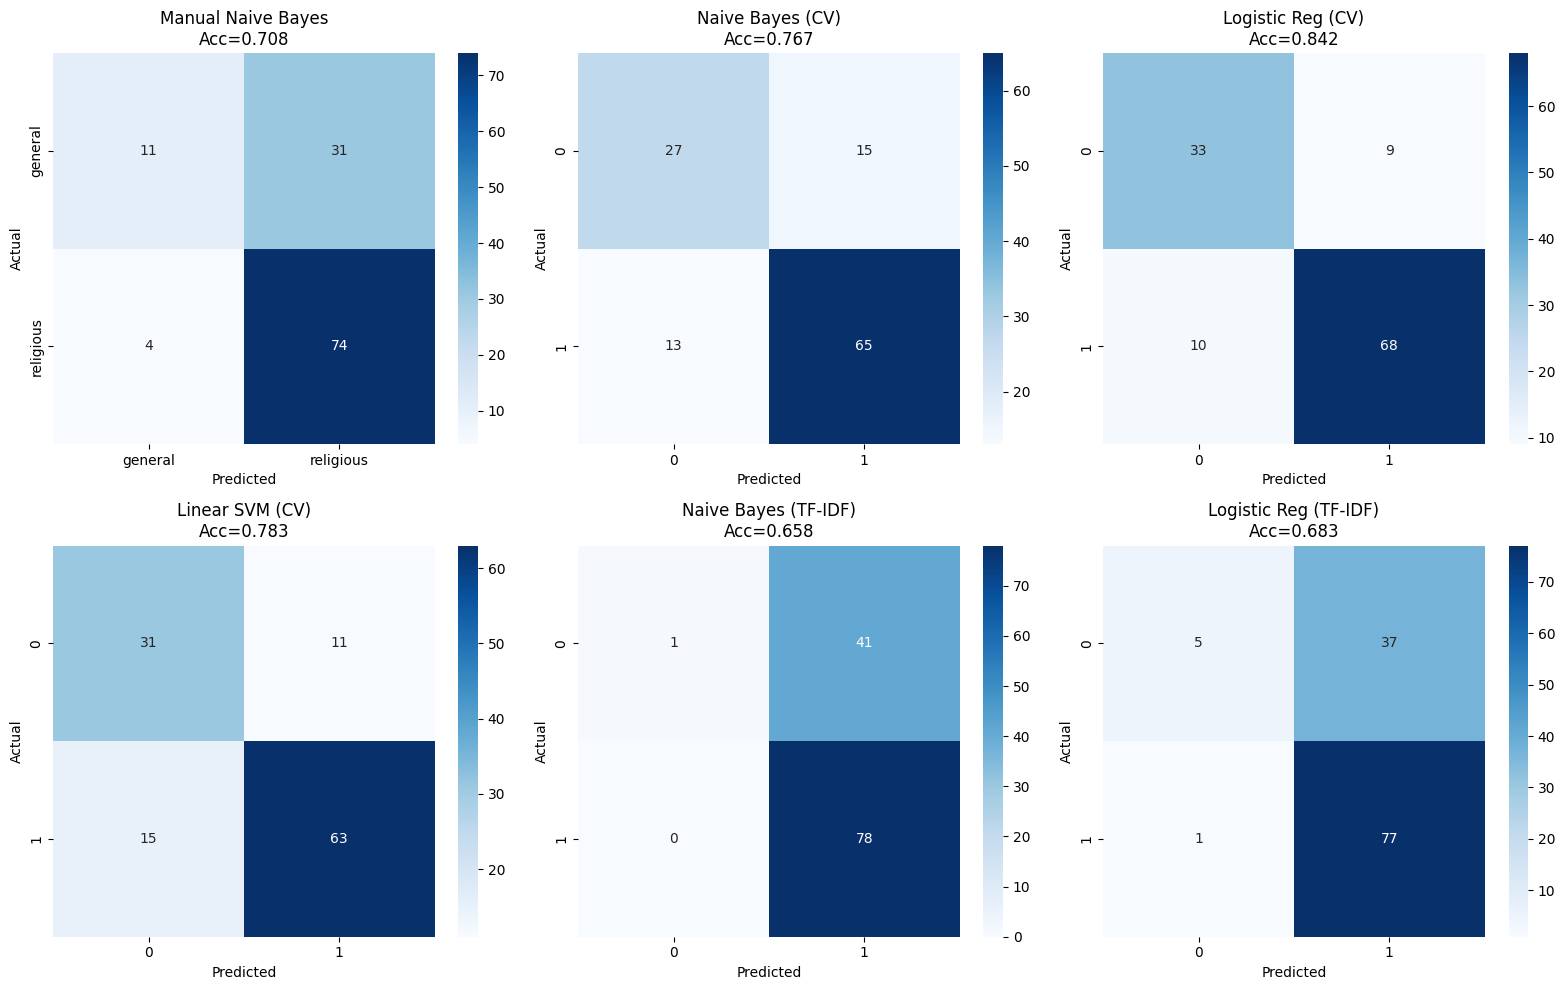

In [ ]:
# Confusion Matrices

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Include manual NB result too
y_test_str   = y_te_raw.tolist()
y_test_enc_list = y_test.tolist()

predictions = [
    (y_pred_manual,              y_test_str,      'Manual Naive Bayes',  True),
    (results[0]['y_pred'],       y_test_enc_list, 'Naive Bayes (CV)',     False),
    (results[1]['y_pred'],       y_test_enc_list, 'Logistic Reg (CV)',    False),
    (results[2]['y_pred'],       y_test_enc_list, 'Linear SVM (CV)',      False),
    (results[3]['y_pred'],       y_test_enc_list, 'Naive Bayes (TF-IDF)', False),
    (results[4]['y_pred'],       y_test_enc_list, 'Logistic Reg (TF-IDF)',False),
]

for i, (y_pred, y_true, title, is_str) in enumerate(predictions):
    cm  = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    labels = ['general','religious'] if is_str else [0, 1]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(f'{title}\nAcc={acc:.3f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()


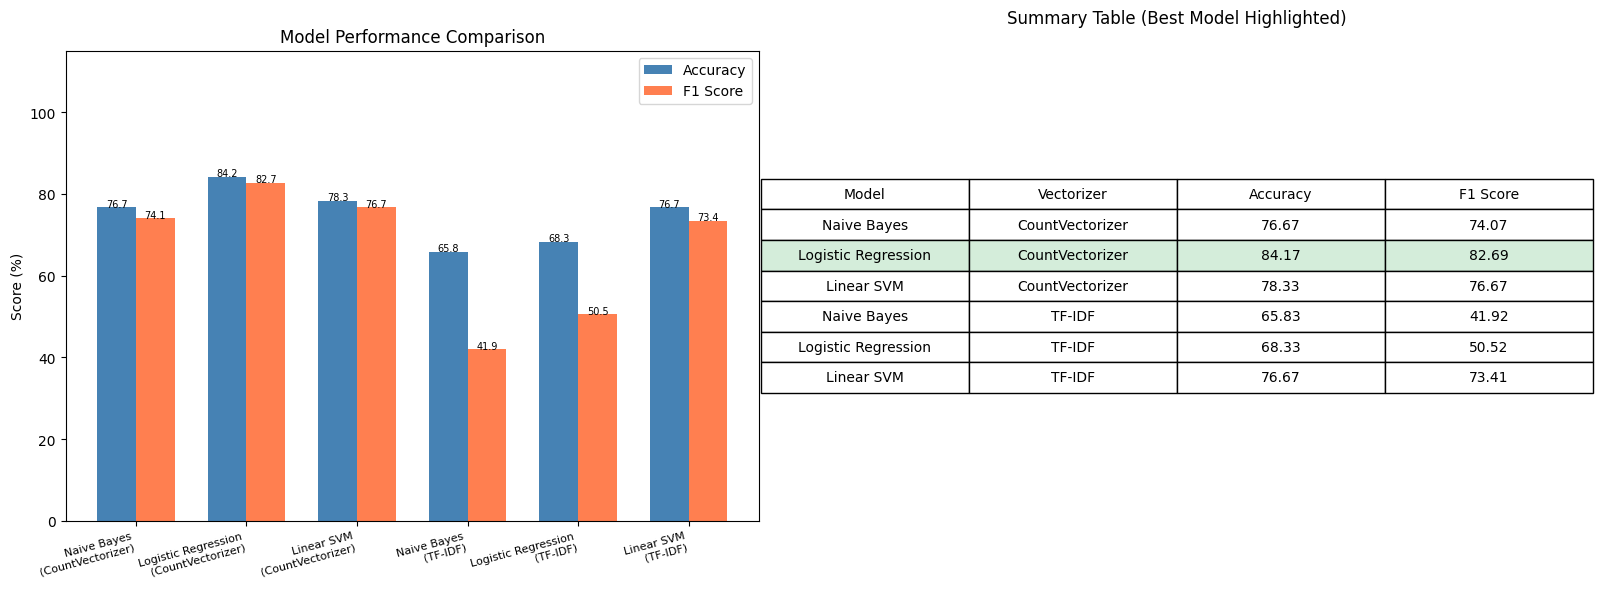


Final Results:
              Model      Vectorizer  Accuracy  F1 Score
        Naive Bayes CountVectorizer     76.67     74.07
Logistic Regression CountVectorizer     84.17     82.69
         Linear SVM CountVectorizer     78.33     76.67
        Naive Bayes          TF-IDF     65.83     41.92
Logistic Regression          TF-IDF     68.33     50.52
         Linear SVM          TF-IDF     76.67     73.41


In [ ]:
# CELL 19 — Bar Chart + Summary Table  (sample Cell 105-110)
# ───────────────────────────────────────────────────────────────

# Convert to percentage
results_df['Accuracy'] = (results_df['Accuracy'] * 100).round(2)
results_df['F1 Score'] = (results_df['F1 Score'] * 100).round(2)

labels_plot = results_df.apply(
    lambda r: f"{r['Model']}\n({r['Vectorizer']})", axis=1)

accuracies = results_df['Accuracy'].values
f1_scores  = results_df['F1 Score'].values

x     = np.arange(len(labels_plot))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].bar(x - width/2, accuracies, width,
                    label='Accuracy', color='steelblue')
bars2 = axes[0].bar(x + width/2, f1_scores,  width,
                    label='F1 Score', color='coral')

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_plot, rotation=15, ha='right', fontsize=8)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Model Performance Comparison')
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', fontsize=7)

# Summary table
axes[1].axis('off')
table_data = results_df[['Model','Vectorizer','Accuracy','F1 Score']].values

table = axes[1].table(
    cellText  = table_data,
    colLabels = ['Model','Vectorizer','Accuracy','F1 Score'],
    cellLoc   = 'center',
    loc       = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Highlight best model row (same as sample)
best_idx = results_df['F1 Score'].idxmax()
for j in range(4):
    table[best_idx + 1, j].set_facecolor('#d4edda')

axes[1].set_title('Summary Table (Best Model Highlighted)', pad=20)

plt.tight_layout()
plt.show()

print("\nFinal Results:")
print(results_df[['Model','Vectorizer','Accuracy','F1 Score']].to_string(index=False))
